In [1]:
# Diabetes datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "uciml/pima-indians-diabetes-database"
)

print(dataset_path)

/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database


In [2]:
# Dataset dosyalarını kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['diabetes.csv']


In [3]:
# CSV dosyasını okuyoruz

import pandas as pd

df = pd.read_csv(dataset_path + "/diabetes.csv")

print(df.shape)

df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 📊 Veri Analizi ve Veri Hazırlama

Bu bölümde diyabet veri seti analiz edilerek eksik veriler, veri tipleri ve istatistiksel dağılımlar incelenecektir.

In [4]:
# Veri tiplerini inceliyoruz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Eksik veri kontrolü

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
# Sayısal istatistikleri inceliyoruz

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 🧹 Veri Temizleme

Gerçek hayatta sıfır olamayacak bazı değerler eksik veri olarak değerlendirilip düzeltilmiştir.

In [7]:
# Sıfır olan değerleri NaN yapıyoruz

import numpy as np

cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in cols:
    
    df[col] = df[col].replace(0, np.nan)

In [8]:
# Eksik verileri kontrol ediyoruz

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [9]:
# Eksik verileri ortalama ile dolduruyoruz

for col in cols:
    
    df[col] = df[col].fillna(df[col].mean())

In [10]:
# Tekrar kontrol ediyoruz

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# 🤖 Makine Öğrenmesi Modeli

Bu bölümde diyabet tahmini için sınıflandırma algoritmaları uygulanacak ve performansları karşılaştırılacaktır.

In [11]:
# Bağımlı ve bağımsız değişkenleri belirliyoruz

X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [12]:
# Train ve test verisini ayırıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# Logistic Regression modelini eğitiyoruz

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7532467532467533


In [14]:
# Random Forest modelini eğitiyoruz

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7467532467532467


In [15]:
# Confusion Matrix oluşturuyoruz

confusion_matrix(y_test, rf_pred)

array([[78, 21],
       [18, 37]])

In [16]:
# Classification Report oluşturuyoruz

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [17]:
# Decision Tree modelini eğitiyoruz

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7207792207792207


In [18]:
# Görselleştirme kütüphanelerini import ediyoruz

import matplotlib.pyplot as plt

import seaborn as sns

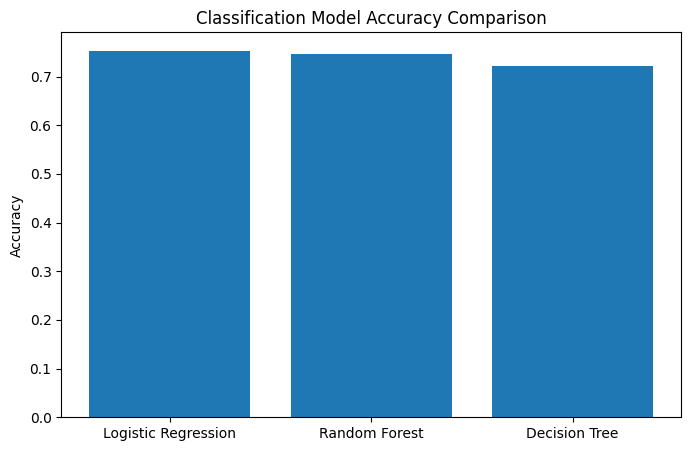

In [19]:
# Modellerin başarı oranlarını karşılaştırıyoruz

models = ["Logistic Regression", "Random Forest", "Decision Tree"]

scores = [lr_acc, rf_acc, dt_acc]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Classification Model Accuracy Comparison")

plt.show()

# ✅ Proje Sonuçları

Bu projede Pima Indians Diabetes veri seti kullanılarak diyabet tahminleme işlemi gerçekleştirilmiştir.

Proje kapsamında:

- Veri analizi yapılmıştır
- Eksik veriler temizlenmiştir
- Classification algoritmaları uygulanmıştır
- Model performansları karşılaştırılmıştır

Uygulanan modeller:

- Logistic Regression
- Random Forest
- Decision Tree

Model sonuçları incelendiğinde en başarılı sonuçların Logistic Regression ve Random Forest modelleri ile elde edildiği gözlemlenmiştir.

Bu proje sayesinde:

- Veri temizleme
- Classification işlemleri
- Accuracy analizi
- Confusion Matrix
- Classification Report
- Makine öğrenmesi modelleme

uygulanmıştır.